# Project 1: Spotting a faulty cogwheel

### Step 1. Importing the libraries and loading the audio files

In [17]:
import numpy as np, matplotlib.pyplot as plt, librosa as lib, os, scipy.signal as sc

In [19]:
folder = 'KIiMD_project1'
file_names = sorted([f for f in os.listdir(folder) if f.endswith('.wav')])
paths = []
sounds = []

#loading the sounds

for f in file_names:
    new_elem = os.path.join(folder, f)
    paths.append(new_elem)
    y, sr = lib.load(new_elem)
    sounds.append(y)


### Step 2. Extracting the metadata and preparing a data frame

In [21]:
parts = [f.split('_') for f in file_names]
print(parts)

[['Z01', 'Pos00', 'RC2', '75k', '0000', '1307031427', '00000', '14', 'Ch1.wav'], ['Z01', 'Pos00', 'RC2', '75k', '0000', '1307031427', '00000', '14', 'Ch2.wav'], ['Z01', 'Pos00', 'RC2', '75k', '0000', '1307031427', '00001', '14', 'Ch1.wav'], ['Z01', 'Pos00', 'RC2', '75k', '0000', '1307031427', '00001', '14', 'Ch2.wav'], ['Z05', 'Pos01', 'RC2', '75k', '0000', '1307031535', '00000', '14', 'Ch1.wav'], ['Z05', 'Pos01', 'RC2', '75k', '0000', '1307031535', '00000', '14', 'Ch2.wav'], ['Z05', 'Pos01', 'RC2', '75k', '0000', '1307031535', '00001', '14', 'Ch1.wav'], ['Z05', 'Pos01', 'RC2', '75k', '0000', '1307031535', '00001', '14', 'Ch2.wav']]


In [23]:
md = []
for j in range(len(file_names)):
     md.append({'fn':file_names[j], 'sig': sounds[j], 'spec': parts[j][0], 'mID': parts[j][4], 
            'time': parts[j][5], 'rid': parts[j][6], 'sID': (parts[j][-1].split('.'))[0]})
print(md[0])

{'fn': 'Z01_Pos00_RC2_75k_0000_1307031427_00000_14_Ch1.wav', 'sig': array([-0.00940022,  0.01897669, -0.0292258 , ...,  0.00154848,
        0.00150205,  0.00194193], dtype=float32), 'spec': 'Z01', 'mID': '0000', 'time': '1307031427', 'rid': '00000', 'sID': 'Ch1'}


### Step 3. Programming a spectrogram display

In [465]:
# logarithmic amplitude scaling is used to amplify the quieter harmonics

def plot_spectrogramm(signal, title, ax):
    ax.imshow(np.log10(np.abs(signal[2]))*20 + 1e-10, 
                   aspect='auto',   
                   origin='lower',  
                   cmap='magma')
    ax.set_title(title, size = 8)



### Step 4. Performing a short-time Fourier transform 

In [468]:
# Higher resolution and Hann window have shown more consistent results. 

for i in range(len(md)):
    signal1 = sc.stft(md[i]['sig'], nperseg=1024, window='hann')
    md[i].update({'stft': signal1})

### Step 5. Plotting the spectrograms

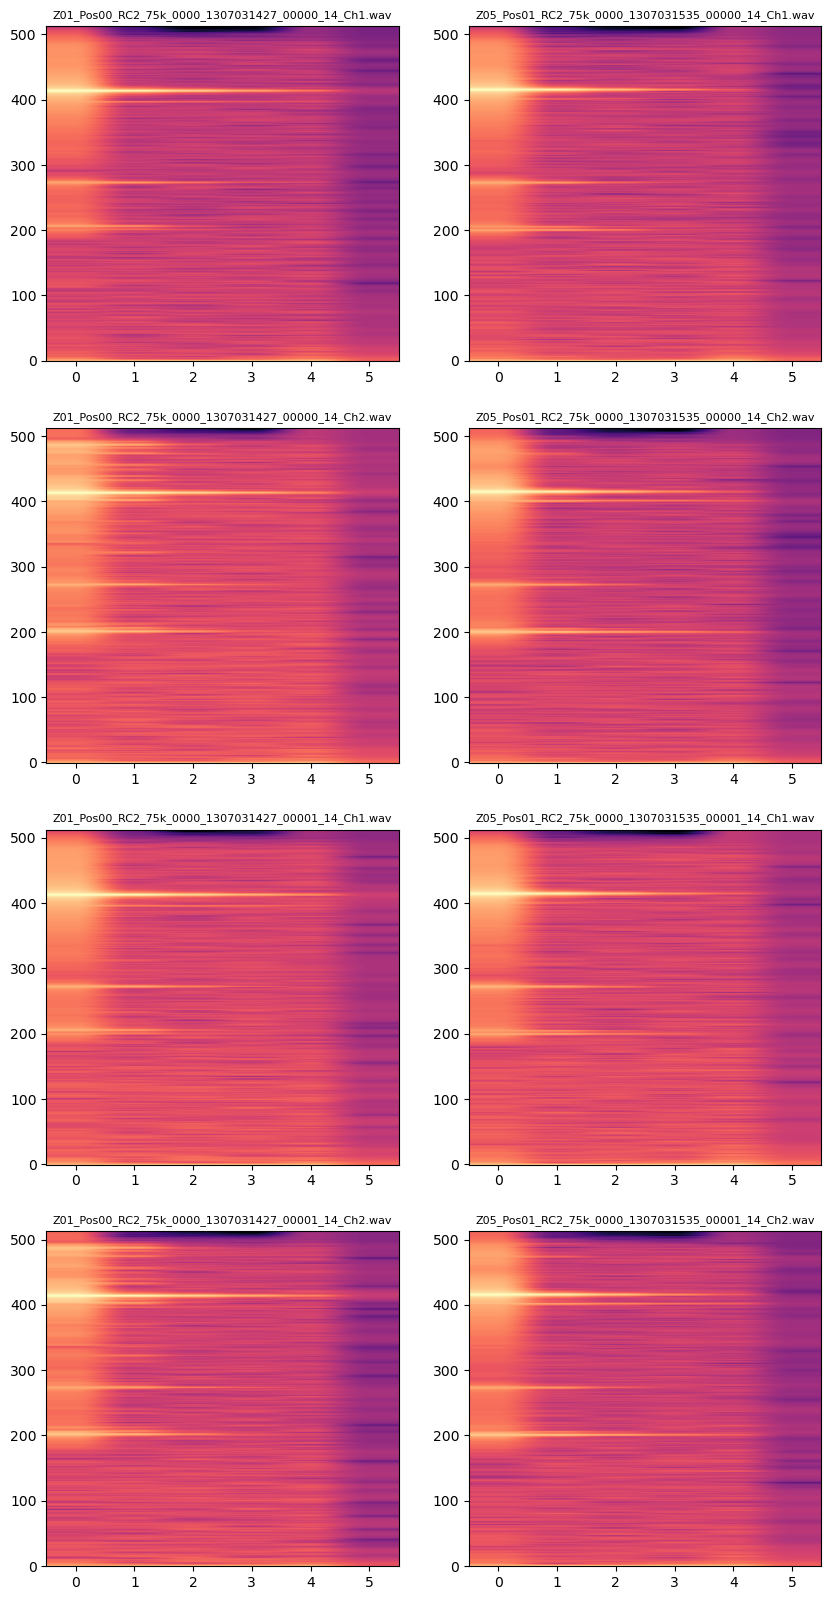

In [471]:
# The first cogwheel (Z01) is on the left, the second one (Z05) is on the right


fig, ax = plt.subplots(nrows=4, ncols=2, figsize = (10, 20))
plot_spectrogramm(md[0]['stft'], md[0]['fn'], ax[0, 0])
plot_spectrogramm(md[4]['stft'], md[4]['fn'], ax[0, 1])
plot_spectrogramm(md[1]['stft'], md[1]['fn'], ax[1, 0])
plot_spectrogramm(md[5]['stft'], md[5]['fn'], ax[1, 1])
plot_spectrogramm(md[2]['stft'], md[2]['fn'], ax[2, 0])
plot_spectrogramm(md[6]['stft'], md[6]['fn'], ax[2, 1])
plot_spectrogramm(md[3]['stft'], md[3]['fn'], ax[3, 0])
plot_spectrogramm(md[7]['stft'], md[7]['fn'], ax[3, 1])



### Step 6. Interpretation

We can see that the second cogwheel Z05 has a few irregularities:
 - the dominant peak at around 400 Hz is almost doubled on spectrograms 2 and 4;
 - the subharmonic at 200 Hz is unusually long and is comparable to the dominant peak
 - this is indicative of a "muddier" sound that is actually audible at high volume 

Therefore, Z05 appears to be faulty